# Shuffle controls for Steinmetz data

This notebook contains three post hoc null controls used to test whether the Early/Mid/Late SPN pattern could arise after disrupting different sources of structure:

1. **ISI shuffle:** independently permute each unit's interspike intervals, preserve its spike count and marginal ISI distribution, and rerun the complete clustering workflow.
2. **Choice-label shuffle:** permute left/right labels within absolute-evidence strata and rerun the complete clustering workflow.
3. **Fast/slow-label shuffle:** keep the original clusters and choice labels fixed, permute fast/slow labels within choice side, and redo only the decision-time-dependent subtype naming.

All controls use 50 repetitions per session and the same six prespecified inequalities. For each original or shuffled dataset, the primary graded score is the percentage of the six criteria that pass (0%, 16.7%, ..., 100%). 

The original data are evaluated once with exactly the same six criteria. Because there is only one original dataset per session, its percentage is a deterministic score and has no confidence interval. For each shuffle control, the bar is the mean percentage across 50 shuffled datasets and the whisker is a reproducible 95% bootstrap confidence interval for that mean. 

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

## Setup and reproducibility

Each session uses its matching seed from `data/source/steinmetz/session_manifest.csv`. The three shuffle controls use reproducible keyed random streams. Choice labels are shuffled within three absolute-evidence strata, and fast/slow labels are shuffled within choice side, so the relevant marginal counts are preserved.

In [2]:
import copy
from typing import Any

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

from spn_figures.clustering import (
    _exact_corr_matrix,
    _stein_cluster_vectors_exact,
    _stein_plot_trial_info_exact,
    _stein_split_fast_slow_exact,
    cluster_steinmetz_session_exact,
)
from spn_figures.config import DERIVED, FIGURES, SOURCE
from spn_figures.datasets import load_steinmetz_session_exact
from spn_figures.io import read_csv, save_figure, write_csv
from spn_figures.isi import (
    STEINMETZ_SESSION_LABELS,
    STEINMETZ_SESSION_ORDER,
    _rng_for_key,
    bar_pattern_scores,
    extract_early_mid_late_bar_means,
    run_steinmetz_isi_shuffle_session,
    strict_bar_pattern_pass,
)

N_SHUFFLES = 50
BASE_SEED = 20260907
N_EVIDENCE_STRATA = 3
N_BOOTSTRAP = 10_000
CRITERION_SCORE_COLUMNS = {
    "pass_choice_left": "chan_dom_L_min",
    "pass_choice_right": "chan_dom_R_min",
    "pass_left_direct": "late_L_d_minus_i",
    "pass_left_indirect": "late_L_i_minus_dR",
    "pass_right_direct": "late_R_d_minus_i",
    "pass_right_indirect": "late_R_i_minus_dL",
}
CRITERION_COLUMNS = tuple(CRITERION_SCORE_COLUMNS)
N_CRITERIA = len(CRITERION_COLUMNS)

source_dir = SOURCE / "steinmetz"
out_dir = DERIVED / "steinmetz"
out_dir.mkdir(parents=True, exist_ok=True)

manifest = read_csv(source_dir / "session_manifest.csv")
manifest = (
    manifest.set_index("session")
    .reindex(STEINMETZ_SESSION_ORDER)
    .reset_index()
)

required = {"session", "folder", "matching_seed", "premove_gap_s"}
missing = required.difference(manifest.columns)
if missing:
    raise ValueError(f"Session manifest is missing columns: {sorted(missing)}")

print(f"Loaded {len(manifest)} Steinmetz sessions; {N_SHUFFLES} shuffles per control and session.")

Loaded 4 Steinmetz sessions; 50 shuffles per control and session.


## Shared label-permutation helpers

In [3]:
def _evidence_strata(
    payload: dict[str, Any],
    trial_entries: np.ndarray,
    n_strata: int = 3,
) -> np.ndarray:
    """Reconstruct the absolute-evidence strata used by the matching routine."""
    evidence = np.asarray(payload["evidence_magnitude_all"], dtype=float).reshape(-1)
    included = np.asarray(payload["included"], dtype=bool).reshape(-1)
    trial_entries = np.asarray(trial_entries, dtype=int).reshape(-1)

    valid = included & np.isfinite(evidence)
    unique_values = np.sort(np.unique(evidence[valid]))
    if unique_values.size < n_strata:
        return np.zeros(trial_entries.size, dtype=int)

    groups = np.array_split(unique_values, n_strata)
    strata = np.full(trial_entries.size, -1, dtype=int)
    entry_evidence = evidence[trial_entries]
    for stratum, values in enumerate(groups):
        strata[np.isin(entry_evidence, values)] = stratum
    return strata


def make_choice_shuffled_payload(
    payload: dict[str, Any],
    repetition: int,
) -> tuple[dict[str, Any], dict[str, float]]:
    """Shuffle Stage-A left/right labels within evidence strata."""
    original_left = np.asarray(payload["trials_left"], dtype=int).reshape(-1)
    original_right = np.asarray(payload["trials_right"], dtype=int).reshape(-1)
    trial_entries = np.concatenate([original_left, original_right])
    original_is_left = np.concatenate(
        [
            np.ones(original_left.size, dtype=bool),
            np.zeros(original_right.size, dtype=bool),
        ]
    )
    strata = _evidence_strata(payload, trial_entries, N_EVIDENCE_STRATA)
    rng = _rng_for_key(
        f"choice-label|{payload['session']}|rep={int(repetition)}",
        base_seed=BASE_SEED,
    )

    shuffled_is_left = original_is_left.copy()
    for stratum in np.unique(strata):
        rows = np.flatnonzero(strata == stratum)
        shuffled_is_left[rows] = rng.permutation(original_is_left[rows])

    shuffled = copy.copy(payload)
    shuffled["trials_left"] = np.sort(trial_entries[shuffled_is_left]).astype(int)
    shuffled["trials_right"] = np.sort(trial_entries[~shuffled_is_left]).astype(int)

    if shuffled["trials_left"].size != original_left.size:
        raise AssertionError("Choice shuffle changed the number of left trial entries.")
    if shuffled["trials_right"].size != original_right.size:
        raise AssertionError("Choice shuffle changed the number of right trial entries.")
    if not np.array_equal(
        np.sort(np.concatenate([shuffled["trials_left"], shuffled["trials_right"]])),
        np.sort(trial_entries),
    ):
        raise AssertionError("Choice shuffle changed the matched trial multiset.")

    for stratum in np.unique(strata):
        rows = strata == stratum
        if shuffled_is_left[rows].sum() != original_is_left[rows].sum():
            raise AssertionError("Choice shuffle changed an evidence-stratum count.")

    metadata = {
        "label_agreement": float(np.mean(shuffled_is_left == original_is_left)),
        "n_trial_entries": int(trial_entries.size),
        "n_unique_trials": int(np.unique(trial_entries).size),
    }
    return shuffled, metadata


def make_speed_shuffle(
    payload: dict[str, Any],
    naming_info: dict[str, np.ndarray],
    true_fast: np.ndarray,
    true_slow: np.ndarray,
    repetition: int,
) -> tuple[np.ndarray, np.ndarray, dict[str, float]]:
    """Shuffle fast/slow labels within left/right choice side."""
    true_fast = np.asarray(true_fast, dtype=int).reshape(-1)
    true_slow = np.asarray(true_slow, dtype=int).reshape(-1)
    trial_entries = np.concatenate([true_fast, true_slow])
    original_is_fast = np.concatenate(
        [
            np.ones(true_fast.size, dtype=bool),
            np.zeros(true_slow.size, dtype=bool),
        ]
    )

    choice = np.asarray(payload["choice"], dtype=int).reshape(-1)
    choice_strata = choice[trial_entries]
    rng = _rng_for_key(
        f"speed-label|{payload['session']}|rep={int(repetition)}",
        base_seed=BASE_SEED,
    )

    shuffled_is_fast = original_is_fast.copy()
    for choice_code in np.unique(choice_strata):
        rows = np.flatnonzero(choice_strata == choice_code)
        shuffled_is_fast[rows] = rng.permutation(original_is_fast[rows])

    shuffled_fast = np.sort(trial_entries[shuffled_is_fast]).astype(int)
    shuffled_slow = np.sort(trial_entries[~shuffled_is_fast]).astype(int)

    if shuffled_fast.size != true_fast.size or shuffled_slow.size != true_slow.size:
        raise AssertionError("Speed shuffle changed the total fast/slow counts.")
    if not np.array_equal(
        np.sort(np.concatenate([shuffled_fast, shuffled_slow])),
        np.sort(trial_entries),
    ):
        raise AssertionError("Speed shuffle changed the naming-trial multiset.")
    for choice_code in np.unique(choice_strata):
        rows = choice_strata == choice_code
        if shuffled_is_fast[rows].sum() != original_is_fast[rows].sum():
            raise AssertionError("Speed shuffle changed fast/slow counts within choice side.")

    metadata = {
        "label_agreement": float(np.mean(shuffled_is_fast == original_is_fast)),
        "n_trial_entries": int(trial_entries.size),
        "n_unique_trials": int(np.unique(trial_entries).size),
    }
    return shuffled_fast, shuffled_slow, metadata

## Shared subtype naming and pattern-scoring helpers

In [4]:
def rename_with_speed_groups(
    result: dict[str, Any],
    fast_trials: np.ndarray,
    slow_trials: np.ndarray,
) -> dict[str, Any]:
    """Hold all clusters fixed and redo only the DT-dependent naming step."""
    renamed = dict(result)
    labels = np.asarray(result["final_labels"], dtype=int)
    names = np.array(["unassigned"] * len(labels), dtype=object)
    names[labels == 0] = "L_sub0"
    names[labels == 1] = "L_sub1"
    names[labels == 2] = "R_sub0"
    names[labels == 3] = "R_sub1"

    corr_fast = _exact_corr_matrix(
        _stein_cluster_vectors_exact(result, np.asarray(fast_trials, dtype=int))
    )
    corr_slow = _exact_corr_matrix(
        _stein_cluster_vectors_exact(result, np.asarray(slow_trials, dtype=int))
    )
    delta = corr_slow - corr_fast

    best_pair = None
    best_drop = np.inf
    for left_label in (0, 1):
        for right_label in (2, 3):
            drop = delta[left_label, right_label]
            if np.isfinite(drop) and drop < best_drop:
                best_drop = float(drop)
                best_pair = (left_label, right_label)

    name_map: dict[int, str] = {}
    if best_pair is not None:
        d_left, d_right = best_pair
        name_map = {
            int(d_left): "dSPN_left",
            int(1 - d_left): "iSPN_left",
            int(d_right): "dSPN_right",
            int(5 - d_right): "iSPN_right",
        }
        for label, name in name_map.items():
            names[labels == label] = name

    renamed.update(
        final_names=names,
        name_map=name_map,
        corr_fast=corr_fast,
        corr_slow=corr_slow,
        corr_drop=float(best_drop) if best_pair is not None else np.nan,
        fast_trials=np.asarray(fast_trials, dtype=int),
        slow_trials=np.asarray(slow_trials, dtype=int),
    )
    return renamed


def add_criterion_pass_columns(table: pd.DataFrame) -> pd.DataFrame:
    """Add the six criterion indicators and their graded percentage score."""
    scored = table.copy()
    success = scored["pipeline_success"].fillna(False).astype(bool)
    for pass_column, score_column in CRITERION_SCORE_COLUMNS.items():
        values = pd.to_numeric(
            scored.get(score_column, pd.Series(np.nan, index=scored.index)),
            errors="coerce",
        )
        scored[pass_column] = success & values.gt(0.0)
    scored["n_criteria_passed"] = (
        scored[list(CRITERION_COLUMNS)].sum(axis=1).astype(int)
    )
    scored["criteria_pass_fraction"] = (
        scored["n_criteria_passed"] / N_CRITERIA
    )
    scored["criteria_pass_percent"] = (
        100.0 * scored["criteria_pass_fraction"]
    )
    return scored


def result_record(
    result: dict[str, Any],
    control: str,
    repetition: int,
    metadata: dict[str, float] | None = None,
) -> dict[str, Any]:
    """Extract the six criterion outcomes and supporting statistics."""
    bar_means = extract_early_mid_late_bar_means(result)
    record: dict[str, Any] = {
        "control": control,
        "session": str(result["session"]),
        "repetition": int(repetition),
        "pipeline_success": True,
        "pattern_pass": strict_bar_pattern_pass(
            bar_means,
            fraction_threshold=1.0,
            margin=0.0,
            late_segment=2,
        ),
        "n_units": int(len(result["unit_ids"])),
        "n_assigned_units": int(np.sum(np.asarray(result["final_labels"]) >= 0)),
        "corr_drop": float(result.get("corr_drop", np.nan)),
    }
    if metadata:
        record.update(metadata)

    record.update({column: False for column in CRITERION_COLUMNS})
    record.update(
        n_criteria_passed=0,
        criteria_pass_fraction=0.0,
        criteria_pass_percent=0.0,
    )

    if bar_means is not None:
        scores = bar_pattern_scores(bar_means, late_segment=2)
        record.update(scores)
        criterion_passes = {
            pass_column: bool(scores[score_column] > 0.0)
            for pass_column, score_column in CRITERION_SCORE_COLUMNS.items()
        }
        record.update(criterion_passes)
        record["n_criteria_passed"] = int(sum(criterion_passes.values()))
        record["criteria_pass_fraction"] = (
            record["n_criteria_passed"] / N_CRITERIA
        )
        record["criteria_pass_percent"] = (
            100.0 * record["criteria_pass_fraction"]
        )
    return record


def failure_record(
    control: str,
    session: str,
    repetition: int,
    error: Exception,
    metadata: dict[str, float] | None = None,
) -> dict[str, Any]:
    record: dict[str, Any] = {
        "control": control,
        "session": str(session),
        "repetition": int(repetition),
        "pipeline_success": False,
        "pattern_pass": False,
        "error": f"{type(error).__name__}: {error}",
    }
    record.update({column: False for column in CRITERION_COLUMNS})
    record.update(
        n_criteria_passed=0,
        criteria_pass_fraction=0.0,
        criteria_pass_percent=0.0,
    )
    if metadata:
        record.update(metadata)
    return record

## Original, non-shuffled data

The original clustering pipeline is run once per session. Each of the same six inequalities is then evaluated, and the original score is the percentage that pass. Thus, a session that meets five of six criteria receives 83.3% rather than being reduced to a binary failure. Each original session has one deterministic score and therefore no confidence interval.

In [5]:
payloads: dict[str, dict[str, Any]] = {}
observed_results: dict[str, dict[str, Any]] = {}
observed_records: list[dict[str, Any]] = []

for row in manifest.itertuples(index=False):
    payload = load_steinmetz_session_exact(
        source_dir / row.folder,
        session_name=row.session,
        matching_seed=int(row.matching_seed),
        premove_gap_s=float(row.premove_gap_s),
    )
    result = cluster_steinmetz_session_exact(payload)
    payloads[row.session] = payload
    observed_results[row.session] = result
    observed_records.append(
        result_record(
            result,
            control="observed",
            repetition=-1,
            metadata={"label_agreement": 1.0},
        )
    )
    print(
        f"{row.session}: {len(result['unit_ids'])} retained units; "
        f"criteria_passed={observed_records[-1]['n_criteria_passed']}/{N_CRITERIA} "
        f"({observed_records[-1]['criteria_pass_percent']:.1f}%)"
    )

observed = add_criterion_pass_columns(pd.DataFrame(observed_records))
write_csv(observed, out_dir / "shuffle_controls_observed.csv")
observed[
    ["session", "n_criteria_passed", "criteria_pass_percent",
     "pattern_pass", "min_required_margin", "corr_drop", "n_units"]
]

observed_mean_criteria_percent = float(observed["criteria_pass_percent"].mean())
print(
    f"Original data: mean {observed_mean_criteria_percent:.1f}% of the six "
    f"criteria passed across {len(observed)} sessions."
)

Hench_2017-06-18: 53 retained units; criteria_passed=6/6 (100.0%)
Lederberg_2017-12-11: 31 retained units; criteria_passed=6/6 (100.0%)
Radnitz_2017-01-12: 50 retained units; criteria_passed=6/6 (100.0%)
Richards_2017-11-01: 35 retained units; criteria_passed=5/6 (83.3%)
Original data: mean 95.8% of the six criteria passed across 4 sessions.


## ISI-shuffle control

For each unit, the ISIs are independently permuted. The full clustering workflow is repeated for every realization. Subtype naming follows the same unshuffled-spike naming rule used in the existing ISI control.

In [6]:
isi_session_runs: list[pd.DataFrame] = []

for row in manifest.itertuples(index=False):
    print(f"Running ISI shuffles for {row.session} ...")
    session_df = run_steinmetz_isi_shuffle_session(
        source_dir / row.folder,
        session_name=row.session,
        matching_seed=int(row.matching_seed),
        premove_gap_s=float(row.premove_gap_s),
        n_shuffles=N_SHUFFLES,
    )
    session_df["control"] = "isi_shuffle"
    isi_session_runs.append(session_df)

isi_runs = add_criterion_pass_columns(
    pd.concat(isi_session_runs, ignore_index=True)
)
print(f"Completed {len(isi_runs):,} ISI-shuffle runs.")

Running ISI shuffles for Hench_2017-06-18 ...
Running ISI shuffles for Lederberg_2017-12-11 ...
Running ISI shuffles for Radnitz_2017-01-12 ...
Running ISI shuffles for Richards_2017-11-01 ...
Completed 200 ISI-shuffle runs.


## Choice-label and fast/slow-label controls

The choice-label control reruns clustering because left/right labels define the 12-dimensional Stage-A feature. The fast/slow control reuses the original clusters and reruns only the step that consumes decision-time labels.

In [7]:
task_records: list[dict[str, Any]] = []

for row in manifest.itertuples(index=False):
    session = row.session
    payload = payloads[session]
    observed_result = observed_results[session]

    naming_info = _stein_plot_trial_info_exact(
        payload,
        matching_seed=int(row.matching_seed),
    )
    true_fast, true_slow, _ = _stein_split_fast_slow_exact(
        naming_info["trials_all"],
        naming_info["reaction_time_s"],
    )

    print(f"Running label shuffles for {session} ...")
    for repetition in range(N_SHUFFLES):
        choice_metadata = None
        try:
            shuffled_payload, choice_metadata = make_choice_shuffled_payload(
                payload,
                repetition,
            )
            shuffled_result = cluster_steinmetz_session_exact(shuffled_payload)
            task_records.append(
                result_record(
                    shuffled_result,
                    control="choice_label_shuffle",
                    repetition=repetition,
                    metadata=choice_metadata,
                )
            )
        except Exception as error:
            task_records.append(
                failure_record(
                    "choice_label_shuffle",
                    session,
                    repetition,
                    error,
                    choice_metadata,
                )
            )

        speed_metadata = None
        try:
            shuffled_fast, shuffled_slow, speed_metadata = make_speed_shuffle(
                payload,
                naming_info,
                true_fast,
                true_slow,
                repetition,
            )
            renamed_result = rename_with_speed_groups(
                observed_result,
                shuffled_fast,
                shuffled_slow,
            )
            task_records.append(
                result_record(
                    renamed_result,
                    control="speed_label_shuffle",
                    repetition=repetition,
                    metadata=speed_metadata,
                )
            )
        except Exception as error:
            task_records.append(
                failure_record(
                    "speed_label_shuffle",
                    session,
                    repetition,
                    error,
                    speed_metadata,
                )
            )

task_runs = add_criterion_pass_columns(pd.DataFrame(task_records))
print(f"Completed {len(task_runs):,} task-label shuffle runs.")

Running label shuffles for Hench_2017-06-18 ...
Running label shuffles for Lederberg_2017-12-11 ...
Running label shuffles for Radnitz_2017-01-12 ...
Running label shuffles for Richards_2017-11-01 ...
Completed 400 task-label shuffle runs.


## Combine and save all null runs

In [8]:
runs = add_criterion_pass_columns(
    pd.concat([isi_runs, task_runs], ignore_index=True, sort=False)
)

control_order = [
    "isi_shuffle",
    "choice_label_shuffle",
    "speed_label_shuffle",
]
runs["control"] = pd.Categorical(runs["control"], categories=control_order, ordered=True)
runs = runs.sort_values(["control", "session", "repetition"]).reset_index(drop=True)
runs["control"] = runs["control"].astype(str)

write_csv(runs, out_dir / "shuffle_control_runs.csv")
print(f"Saved {len(runs):,} runs across three controls.")
runs.groupby(["control", "session"])["criteria_pass_percent"].agg(
    ["mean", "std", "count"]
)

Saved 600 runs across three controls.


mean        std  count
control              session                                          
choice_label_shuffle Hench_2017-06-18      69.333333  19.737506     50
                     Lederberg_2017-12-11  49.333333  32.464877     50
                     Radnitz_2017-01-12    63.333333  21.560441     50
                     Richards_2017-11-01   62.666667  23.221305     50
isi_shuffle          Hench_2017-06-18      34.333333  34.075081     50
                     Lederberg_2017-12-11   7.666667  21.351714     50
                     Radnitz_2017-01-12     6.666667  21.028002     50
                     Richards_2017-11-01   39.666667  35.617329     50
speed_label_shuffle  Hench_2017-06-18      64.000000  23.172429     50
                     Lederberg_2017-12-11  66.666667  26.937401     50
                     Radnitz_2017-01-12    68.666667  21.728066     50
                     Richards_2017-11-01   64.666667  16.714218     50

## Per-session summaries

For each session and control, the null bar is the mean percentage of the six criteria passed across 50 shuffled datasets. Whiskers are reproducible 95% bootstrap confidence intervals for that mean, obtained by resampling the 50 shuffle-level percentages. The original-data value is the percentage of criteria passed by the single unshuffled dataset for that session. Pipeline failures, if any, are conservatively assigned 0%. The strict all-six pass counts are retained in the tables as a secondary diagnostic.

In [9]:
def bootstrap_mean_interval(
    values: np.ndarray,
    key: str,
    n_bootstrap: int = N_BOOTSTRAP,
    confidence: float = 0.95,
) -> tuple[float, float]:
    """Percentile bootstrap CI for the mean across shuffle repetitions."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan, np.nan
    if values.size == 1:
        return float(values[0]), float(values[0])

    rng = _rng_for_key(f"criteria-bootstrap|{key}", base_seed=BASE_SEED)
    indices = rng.integers(0, values.size, size=(int(n_bootstrap), values.size))
    bootstrap_means = values[indices].mean(axis=1)
    alpha = 1.0 - confidence
    low, high = np.quantile(bootstrap_means, [alpha / 2.0, 1.0 - alpha / 2.0])
    return float(low), float(high)


summary_rows: list[dict[str, Any]] = []
for (control, session), group in runs.groupby(["control", "session"], sort=False):
    original_row = observed.loc[observed["session"] == session].iloc[0]
    total = int(len(group))
    passes = int(group["pattern_pass"].sum())
    null_criteria_percent = pd.to_numeric(
        group["criteria_pass_percent"], errors="coerce"
    ).to_numpy(float)
    null_mean_criteria_percent = float(np.nanmean(null_criteria_percent))
    ci_low, ci_high = bootstrap_mean_interval(
        null_criteria_percent, key=f"{control}|{session}"
    )
    original_criteria_percent = float(original_row["criteria_pass_percent"])
    p_criteria = (
        1 + np.sum(null_criteria_percent >= original_criteria_percent)
    ) / (total + 1)

    margin_null = pd.to_numeric(
        group.get("min_required_margin", pd.Series(np.nan, index=group.index)),
        errors="coerce",
    ).to_numpy(float)
    margin_for_test = np.where(np.isfinite(margin_null), margin_null, -np.inf)
    original_margin = float(original_row["min_required_margin"])
    p_margin = (1 + np.sum(margin_for_test >= original_margin)) / (total + 1)

    corr_null = pd.to_numeric(
        group.get("corr_drop", pd.Series(np.nan, index=group.index)),
        errors="coerce",
    ).to_numpy(float)
    original_corr = float(original_row["corr_drop"])
    if np.isfinite(corr_null).any() and np.isfinite(original_corr):
        corr_for_test = np.where(np.isfinite(corr_null), corr_null, np.inf)
        p_corr = (1 + np.sum(corr_for_test <= original_corr)) / (total + 1)
        null_median_corr = float(np.nanmedian(corr_null))
    else:
        p_corr = np.nan
        null_median_corr = np.nan

    label_agreement = pd.to_numeric(
        group.get("label_agreement", pd.Series(np.nan, index=group.index)),
        errors="coerce",
    )

    summary_rows.append(
        {
            "control": control,
            "session": session,
            "n_shuffles": total,
            "n_pipeline_success": int(group["pipeline_success"].sum()),
            "null_mean_criteria_pass_percent": null_mean_criteria_percent,
            "null_mean_criteria_pass_ci95_low_percent": ci_low,
            "null_mean_criteria_pass_ci95_high_percent": ci_high,
            "original_n_criteria_passed": int(original_row["n_criteria_passed"]),
            "original_criteria_pass_percent": original_criteria_percent,
            "p_criteria_pass_percent": float(p_criteria),
            "null_pattern_pass_count": passes,
            "null_pattern_pass_rate": passes / total,
            "original_pattern_pass": bool(original_row["pattern_pass"]),
            "original_pattern_pass_value": float(original_row["pattern_pass"]),
            "original_min_required_margin": original_margin,
            "null_median_min_required_margin": float(
                np.nanmedian(margin_null) if np.isfinite(margin_null).any() else np.nan
            ),
            "p_min_required_margin": float(p_margin),
            "original_corr_drop": original_corr,
            "null_median_corr_drop": null_median_corr,
            "p_corr_drop": p_corr,
            "mean_label_agreement": float(label_agreement.mean()) if label_agreement.notna().any() else np.nan,
        }
    )

summary = pd.DataFrame(summary_rows)
summary["control"] = pd.Categorical(summary["control"], categories=control_order, ordered=True)
summary["session"] = pd.Categorical(
    summary["session"], categories=STEINMETZ_SESSION_ORDER, ordered=True
)
summary = summary.sort_values(["control", "session"]).reset_index(drop=True)
summary["control"] = summary["control"].astype(str)
summary["session"] = summary["session"].astype(str)

write_csv(summary, out_dir / "shuffle_control_summary.csv")
display(
    summary[
        [
            "control",
            "session",
            "original_n_criteria_passed",
            "original_criteria_pass_percent",
            "n_shuffles",
            "null_mean_criteria_pass_percent",
            "null_mean_criteria_pass_ci95_low_percent",
            "null_mean_criteria_pass_ci95_high_percent",
            "p_criteria_pass_percent",
        ]
    ]
)

,control,session,original_n_criteria_passed,original_criteria_pass_percent,n_shuffles,null_mean_criteria_pass_percent,null_mean_criteria_pass_ci95_low_percent,null_mean_criteria_pass_ci95_high_percent,p_criteria_pass_percent
0,isi_shuffle,Hench_2017-06-18,6,100.000000,50,34.333333,25.000000,43.666667,0.058824
1,isi_shuffle,Lederberg_2017-12-11,6,100.000000,50,7.666667,2.333333,14.000000,0.019608
2,isi_shuffle,Radnitz_2017-01-12,6,100.000000,50,6.666667,1.658333,13.000000,0.019608
3,isi_shuffle,Richards_2017-11-01,5,83.333333,50,39.666667,29.666667,49.333333,0.176471
4,choice_label_shuffle,Hench_2017-06-18,6,100.000000,50,69.333333,64.000000,74.666667,0.137255
5,choice_label_shuffle,Lederberg_2017-12-11,6,100.000000,50,49.333333,40.000000,58.333333,0.058824
6,choice_label_shuffle,Radnitz_2017-01-12,6,100.000000,50,63.333333,57.333333,69.000000,0.098039
7,choice_label_shuffle,Richards_2017-11-01,5,83.333333,50,62.666667,56.000000,68.666667,0.313725
8,speed_label_shuffle,Hench_2017-06-18,6,100.000000,50,64.000000,57.333333,70.666667,0.215686
9,speed_label_shuffle,Lederberg_2017-12-11,6,100.000000,50,66.666667,59.333333,74.000000,0.333333


## Across-session comparison

For the across-session comparison, the original statistic is the mean percentage of criteria passed across the four sessions. For each shuffle repetition, the same repetition number is combined across sessions and the mean criterion-pass percentage is calculated. The Monte Carlo p-value is the fraction of joint null repetitions producing a mean percentage at least as large as the original value, with the standard plus-one correction. The number of sessions meeting all six criteria is retained as a secondary diagnostic.

In [10]:
joint_runs = (
    runs.groupby(["control", "repetition"], as_index=False)
    .agg(
        n_sessions=("session", "size"),
        mean_criteria_pass_percent_across_sessions=("criteria_pass_percent", "mean"),
        n_sessions_all_six_pass=("pattern_pass", "sum"),
    )
)

observed_mean_criteria_percent = float(observed["criteria_pass_percent"].mean())
observed_all_six_count = int(observed["pattern_pass"].sum())

joint_rows: list[dict[str, Any]] = []
for control, group in joint_runs.groupby("control", sort=False):
    total = int(len(group))
    null_joint_percent = group["mean_criteria_pass_percent_across_sessions"].to_numpy(float)
    ci_low, ci_high = bootstrap_mean_interval(
        null_joint_percent, key=f"joint|{control}"
    )
    joint_rows.append(
        {
            "control": control,
            "original_mean_criteria_pass_percent": observed_mean_criteria_percent,
            "original_sessions_all_six_pass": observed_all_six_count,
            "original_total_sessions": len(STEINMETZ_SESSION_ORDER),
            "n_joint_shuffles": total,
            "null_mean_criteria_pass_percent": float(np.mean(null_joint_percent)),
            "null_mean_criteria_pass_ci95_low_percent": ci_low,
            "null_mean_criteria_pass_ci95_high_percent": ci_high,
            "null_mean_sessions_all_six_pass": float(
                group["n_sessions_all_six_pass"].mean()
            ),
            "null_repetitions_at_least_original_percent": int(
                np.sum(null_joint_percent >= observed_mean_criteria_percent)
            ),
            "p_at_least_original_mean_criteria_percent": float(
                (1 + np.sum(null_joint_percent >= observed_mean_criteria_percent))
                / (total + 1)
            ),
        }
    )

joint_summary = pd.DataFrame(joint_rows)
joint_summary["control"] = pd.Categorical(
    joint_summary["control"], categories=control_order, ordered=True
)
joint_summary = joint_summary.sort_values("control").reset_index(drop=True)
joint_summary["control"] = joint_summary["control"].astype(str)

write_csv(joint_runs, out_dir / "shuffle_control_joint_runs.csv")
write_csv(joint_summary, out_dir / "shuffle_control_joint_summary.csv")
joint_summary

,control,original_mean_criteria_pass_percent,original_sessions_all_six_pass,original_total_sessions,n_joint_shuffles,null_mean_criteria_pass_percent,null_mean_criteria_pass_ci95_low_percent,null_mean_criteria_pass_ci95_high_percent,null_mean_sessions_all_six_pass,null_repetitions_at_least_original_percent,p_at_least_original_mean_criteria_percent
0,isi_shuffle,95.833333,3,4,50,22.083333,18.333333,25.835417,0.10,0,0.019608
1,choice_label_shuffle,95.833333,3,4,50,61.166667,57.414583,64.833333,0.30,0,0.019608
2,speed_label_shuffle,95.833333,3,4,50,66.000000,62.666667,69.333333,0.76,1,0.039216


## Figure: original pattern versus three shuffle controls

Blue bars show the mean percentage of the six criteria passed across 50 shuffled datasets, and black whiskers show 95% bootstrap confidence intervals for those means. Black diamonds show the percentage passed by the corresponding original session. 

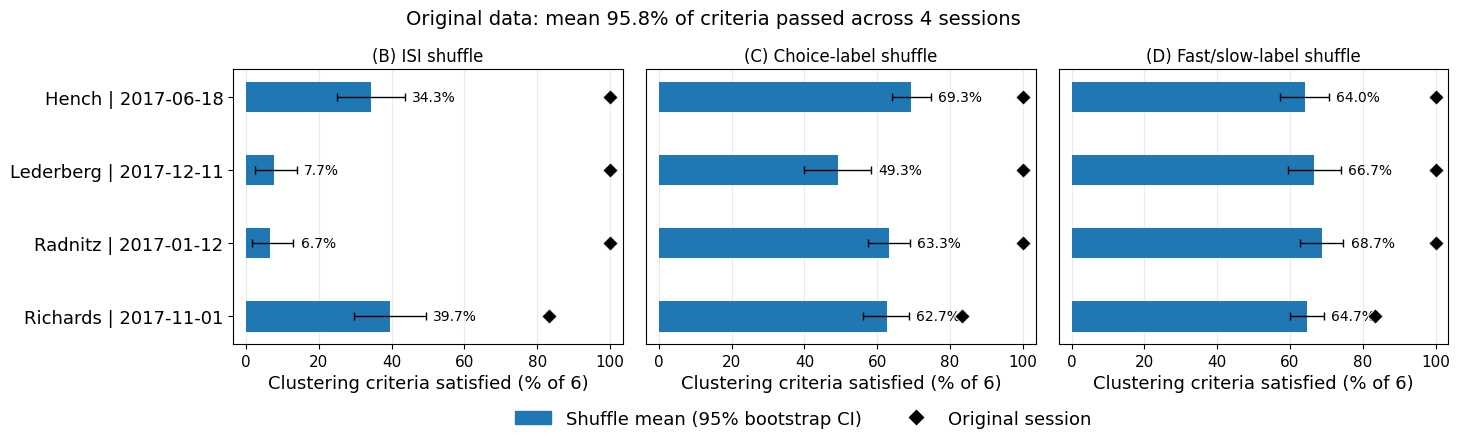

In [12]:
titles = ("(B) ISI shuffle", "(C) Choice-label shuffle", "(D) Fast/slow-label shuffle")
xticks = np.arange(0, 101, 20)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
fig.subplots_adjust(left=0.18, right=0.99, bottom=0.23, top=0.78, wspace=0.06)

for ax, control, title in zip(axes, control_order, titles):
    data = (summary[summary["control"].eq(control)]
            .set_index("session").reindex(STEINMETZ_SESSION_ORDER).reset_index())

    values = data["null_mean_criteria_pass_percent"].to_numpy(float)
    low = data["null_mean_criteria_pass_ci95_low_percent"].to_numpy(float)
    high = data["null_mean_criteria_pass_ci95_high_percent"].to_numpy(float)
    original = data["original_criteria_pass_percent"].to_numpy(float)
    y = np.arange(len(data))

    bars = ax.barh(y, values, height=0.42, color="#1f77b4", zorder=2)
    ax.errorbar(values, y, xerr=[np.maximum(values - low, 0.0),
                                  np.maximum(high - values, 0.0)],
                fmt="none", ecolor="black", capsize=3, linewidth=1, zorder=3)
    ax.scatter(original, y, marker="D", s=60, color="black",
               edgecolor="white", linewidth=0.6, zorder=4, clip_on=False)

    ax.set(yticks=y, xlim=(-3.5, 103.5), xticks=xticks, title=title)
    ax.set_xlabel("Clustering criteria satisfied (% of 6)", fontsize=13)
    ax.set_xticklabels([f"{x:.0f}" for x in xticks])
    ax.tick_params(axis="x", labelsize=11)
    ax.grid(axis="x", alpha=0.25, zorder=1)

    if ax is axes[0]:
        ax.set_yticklabels(
            [STEINMETZ_SESSION_LABELS[s] for s in data["session"]],
            fontsize=11,
        )
    else:
        ax.tick_params(axis="y", left=False, labelleft=False)

    for bar, value, right in zip(bars, values, high):
        ax.text(min(right + 2.0, 91.0), bar.get_y() + bar.get_height() / 2,
                f"{value:.1f}%", va="center", fontsize=10)

axes[0].invert_yaxis()
axes[0].tick_params(axis="y", labelsize=13)

fig.suptitle(
    f"Original data: mean {observed_mean_criteria_percent:.1f}% of criteria passed "
    f"across {len(observed)} sessions",
    y=0.9, fontsize=14,
)

fig.legend(
    handles=[
        Patch(color="#1f77b4", label="Shuffle mean (95% bootstrap CI)"),
        Line2D([], [], marker="D", linestyle="none", color="black", markersize=9,
               markeredgecolor="white", label="Original session"),
    ],
    loc="lower center", bbox_to_anchor=(0.56, 0.03),
    ncol=2, frameon=False, fontsize=13,
)

save_figure(fig, FIGURES / "supporting" / "FigSX_steinmetz_shuffle_controls")
plt.show()